# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [4]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


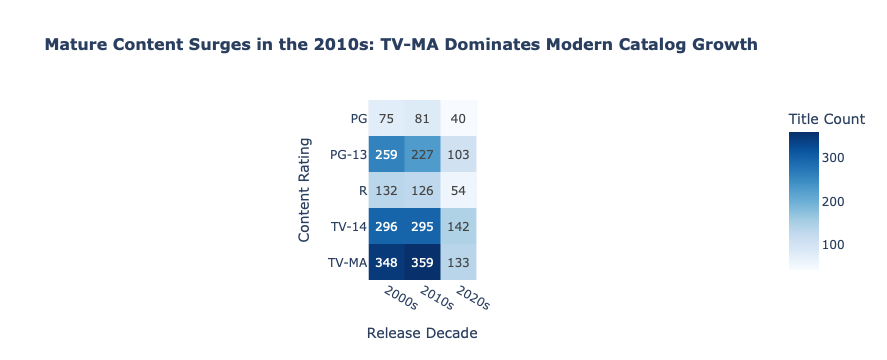

In [7]:
# Task 1
# YOUR CODE HERE
# Task 1
import pandas as pd
import plotly.express as px

# 1. Create the 'decade' column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# 2. Filter to the most common ratings
target_ratings = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
df_filtered = df[df['rating'].isin(target_ratings)]

# 3. Aggregate data by rating and decade to count titles
heatmap_data = (
    df_filtered.groupby(['rating', 'decade']).size().reset_index(name='count')
)

# 4. Pivot the data into a matrix form for the heatmap
heatmap_matrix = heatmap_data.pivot(
    index='rating', columns='decade', values='count'
).fillna(0)

# 5. Build the heatmap with a sequential Blues color scale
fig1 = px.imshow(
    heatmap_matrix,
    labels=dict(x="Release Decade", y="Content Rating", color="Title Count"),
    x=heatmap_matrix.columns,
    y=heatmap_matrix.index,
    color_continuous_scale='Blues',
    text_auto=True,
    title="<b>Mature Content Surges in the 2010s: TV-MA Dominates Modern Catalog Growth</b>",
)

# Tweak layout adjustments for clean readability
fig1.update_layout(
    title_font_size=16, xaxis_nticks=len(heatmap_matrix.columns)
)

fig1.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


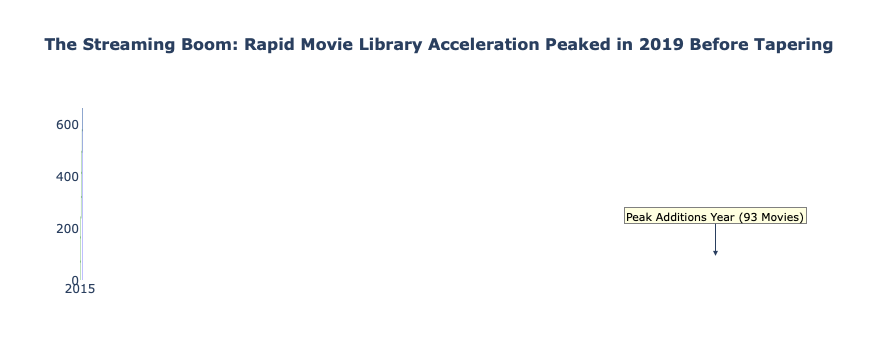

In [10]:
# Task 2
import pandas as pd
import plotly.graph_objects as go

# 1. Filter to Movies only and drop missing years
df_movies = df[df['type'] == 'Movie'].dropna(subset=['added_year'])

# 2. Filter for years between 2015 and 2022, then count titles per year
df_yearly_movies = (
    df_movies[df_movies['added_year'].between(2015, 2022)]
    .groupby('added_year')
    .size()
    .reset_index(name='count')
)

# 3. Force the years to strings immediately so Plotly treats them as categories
years = df_yearly_movies['added_year'].astype(int).astype(str).tolist()
counts = df_yearly_movies['count'].tolist()

# Find the year with the maximum single addition for our required annotation
max_idx = counts.index(max(counts))
max_year = years[max_idx]
max_count = counts[max_idx]

# 4. Append the final cumulative total bar configuration
years.append("Total Catalog")
counts.append(sum(counts))

# Define measure array: 'relative' for additions, 'total' for the last bar
measures = ["relative"] * (len(years) - 1) + ["total"]

# 5. Build the Waterfall chart using specific color styling rules
fig2 = go.Figure(
    go.Waterfall(
        name="Movie Additions",
        orientation="v",
        measure=measures,
        x=years,
        textposition="outside",
        text=[f"+{c}" if m == "relative" else f"{c}" for c, m in zip(counts, measures)],
        y=counts,
        increasing=dict(marker=dict(color="green")),  # Green for additions
        totals=dict(marker=dict(color="blue")),  # Blue for final total
    )
)

# 6. CRITICAL FIX: Explicitly force layout to 'category' type
fig2.update_layout(
    title="<b>The Streaming Boom: Rapid Movie Library Acceleration Peaked in 2019 Before Tapering</b>",
    title_font_size=16,
    showlegend=False,
    paper_bgcolor="white",
    plot_bgcolor="white",
    xaxis=dict(type='category'),  # <--- This splits the years into separate bars!
    annotations=[
        dict(
            x=max_year,
            y=max_count,
            xref="x",
            yref="y",
            text=f"Peak Additions Year ({max_count} Movies)",
            showarrow=True,
            arrowhead=2,
            ax=0,
            ay=-40,
            font=dict(color="black", size=11),
            bgcolor="lightyellow",
            bordercolor="gray",
        )
    ],
)

fig2.show()